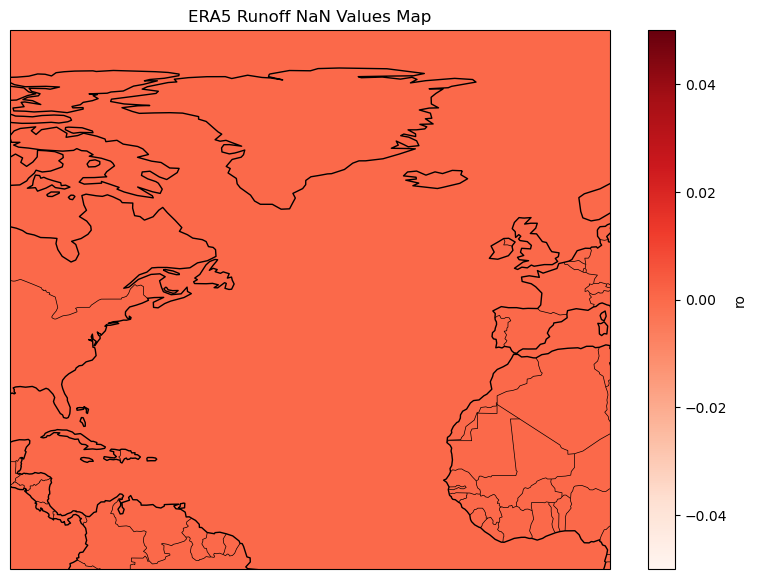

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# File path
file_path = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ERA5\runoff_full.nc"

# Load dataset
ds = xr.open_dataset(file_path)

# Variable names
time_name = "valid_time" if "valid_time" in ds.coords else "time"
lat_name = "latitude"
lon_name = "longitude"

# Runoff variable
runoff = ds["ro"]

# Create NaN mask
nan_mask = runoff.isnull()

nan_map = nan_mask.any(dim=time_name)

# Plot
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=ccrs.PlateCarree())

nan_map.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="Reds",
    add_colorbar=True
)

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.LAND, facecolor="lightgrey")

ax.set_title("ERA5 Runoff NaN Values Map")

plt.show()